In [1]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

#plotting library
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Model
from catboost import CatBoostClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
dataset=pd.read_csv("maize_seed_variety.csv")

In [4]:
dataset.head()

,soil_type,sowing_month,harvest_month,water_source,soil_ph,temperature,nitrogen_N,phosphorus_P,potassium_K,seed_variety
0,Sandy Loam,Jun,Sep,irrigated,5.7,24.0,161.0,87.6,84.5,Borloo YH-1898
1,Clay Loam,Jul,Oct,rainfed,6.9,24.2,121.1,71.6,82.6,NK-6240
2,Loamy soil,Jun,Sep,irrigated,6.6,20.9,166.3,64.0,76.1,Pioneer 30Y87
3,Sandy Loam,Jul,Oct,rainfed,5.9,19.4,140.6,78.4,78.7,DK-919
4,Loamy soil,Jun,Sep,irrigated,6.6,24.9,159.1,73.6,73.1,DK-5219


In [5]:
#before dropping shape
dataset.shape

(1000, 10)

In [6]:
#checking null values

dataset.isnull().sum()

,0
soil_type,0
sowing_month,0
harvest_month,0
water_source,0
soil_ph,0
temperature,0
nitrogen_N,0
phosphorus_P,0
potassium_K,0
seed_variety,0


In [7]:
# checking duplicates
sum(dataset.duplicated())

0

In [8]:
dataset=dataset.dropna()

In [9]:
#dataset info
print(dataset.info())
print(dataset.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   soil_type      1000 non-null   object 
 1   sowing_month   1000 non-null   object 
 2   harvest_month  1000 non-null   object 
 3   water_source   1000 non-null   object 
 4   soil_ph        1000 non-null   float64
 5   temperature    1000 non-null   float64
 6   nitrogen_N     1000 non-null   float64
 7   phosphorus_P   1000 non-null   float64
 8   potassium_K    1000 non-null   float64
 9   seed_variety   1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 78.3+ KB
None
           soil_ph  temperature   nitrogen_N  phosphorus_P  potassium_K
count  1000.000000  1000.000000  1000.000000   1000.000000  1000.000000
mean      6.251200    22.493300   149.629000     74.883600    75.365600
std       0.443165     2.521246    17.476852      8.538086     8.728549
min       5.500000  

In [10]:
# dropping columns
dropped_columns=["harvest_month","sowing_month"]
dataset=dataset.drop(dropped_columns, axis=1)

In [11]:
#updated shape
dataset.shape

(1000, 8)

In [12]:
dataset_columns=dataset.columns
print(dataset_columns)

Index(['soil_type', 'water_source', 'soil_ph', 'temperature', 'nitrogen_N',
       'phosphorus_P', 'potassium_K', 'seed_variety'],
      dtype='object')


In [13]:
# defining columns
categorical_cols = [
    'soil_type',
    'water_source'
]

numerical_cols = [
    'soil_ph',
    'temperature',
    'nitrogen_N',
    'phosphorus_P',
    'potassium_K'
]

target_col = 'seed_variety'

In [14]:
for col in categorical_cols:
  print(dataset[col].value_counts())

soil_type
Sandy Loam    507
Loamy soil    315
Clay Loam     178
Name: count, dtype: int64
water_source
irrigated    500
rainfed      500
Name: count, dtype: int64


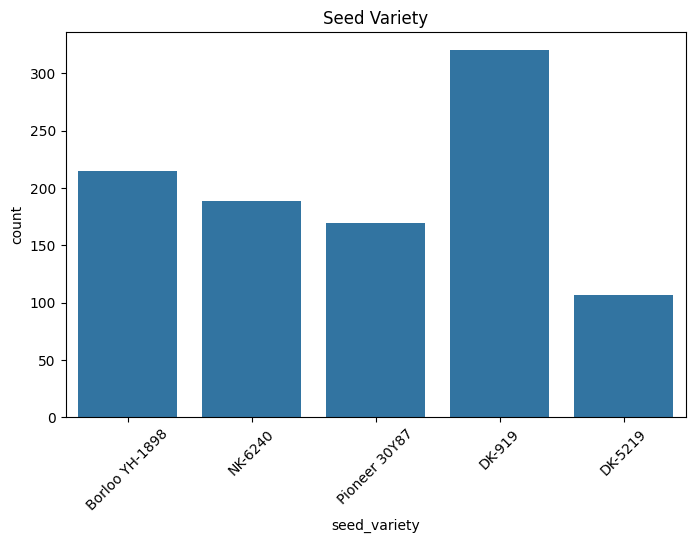

In [15]:
#plotting output columns

plt.figure(figsize=(8,5))
sns.countplot(x=dataset[target_col])
plt.title('Seed Variety')
plt.xticks(rotation=45)
plt.show()

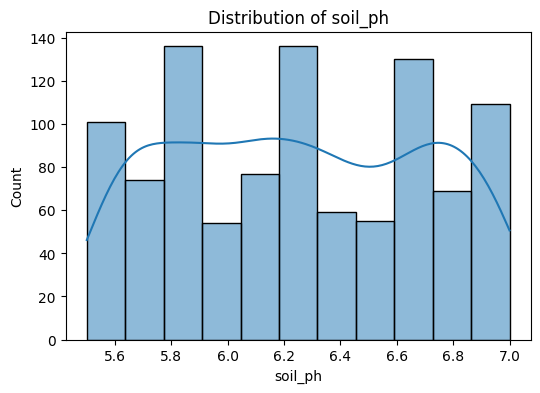

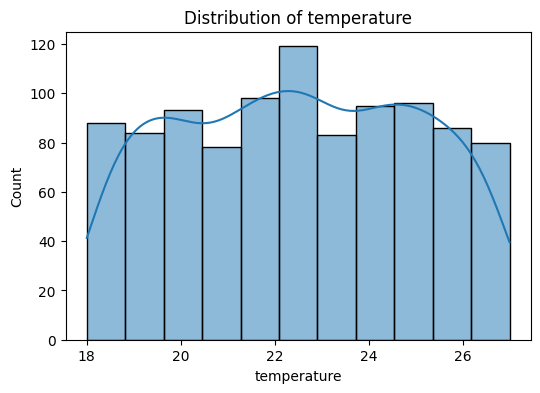

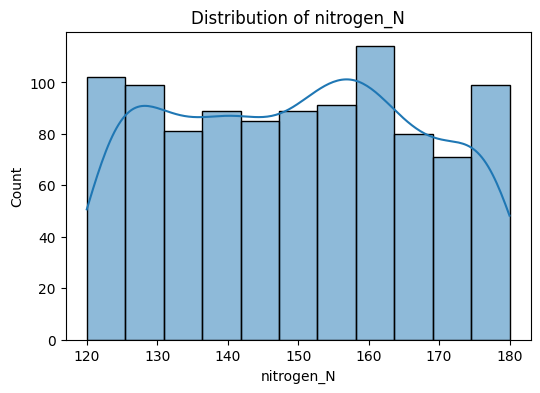

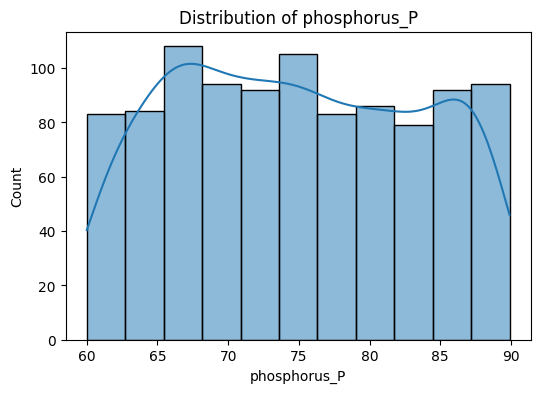

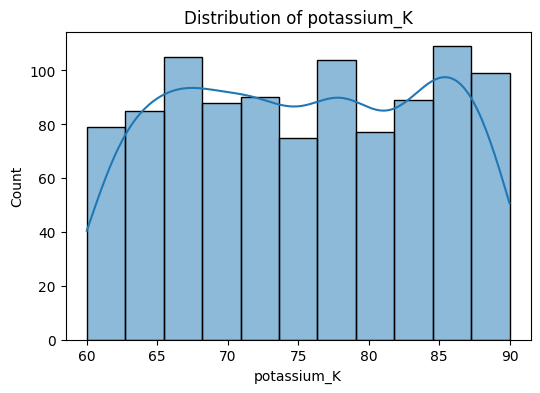

In [16]:
#checking distribution of input numerical columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

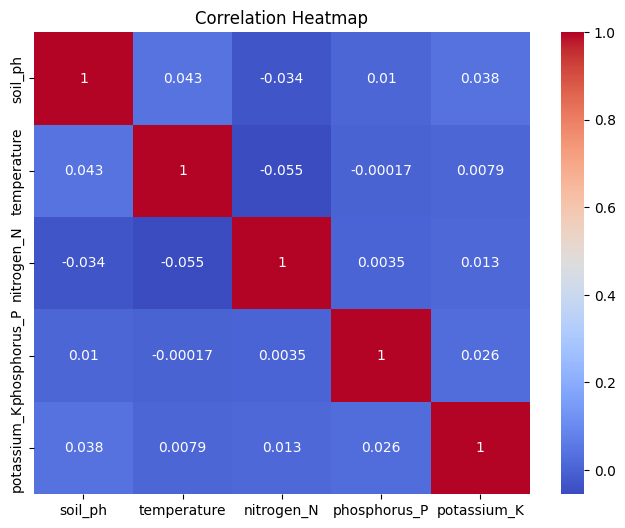

In [17]:
#checking correlation between numerical values

plt.figure(figsize=(8,6))

sns.heatmap(
    dataset[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

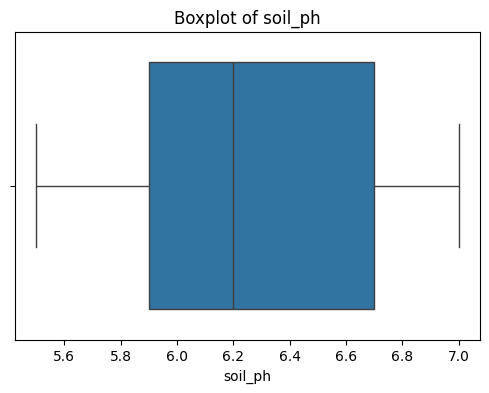

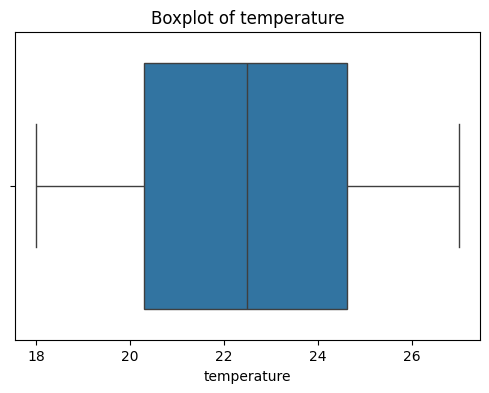

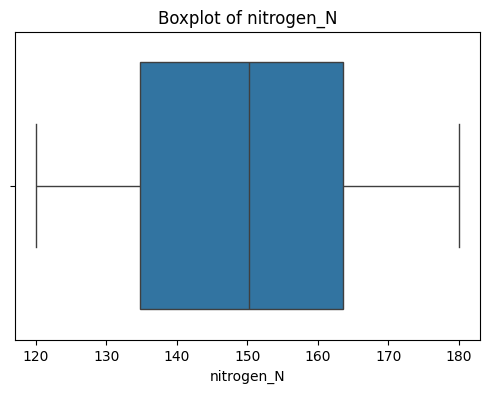

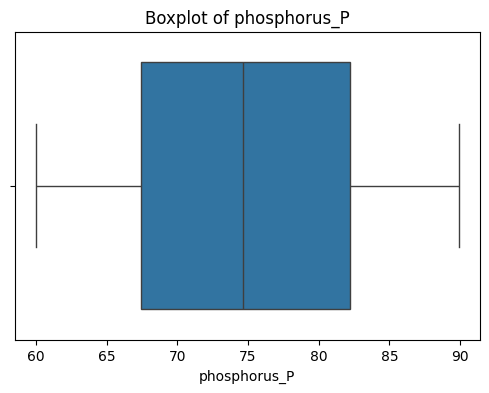

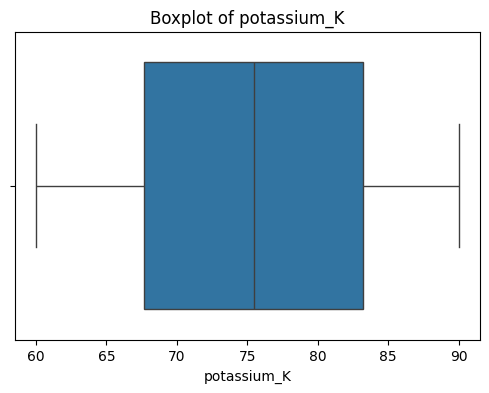

In [18]:
#plotting for outlier check
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [19]:
#splitting targeted and inout columns
X = dataset.drop(target_col, axis=1)
y = dataset[target_col]

In [21]:
#encoding of targeted column
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Borloo YH-1898' 'DK-5219' 'DK-919' 'NK-6240' 'Pioneer 30Y87']


In [22]:
#splitiing before applying SMOTE technique to prevent data leak

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (800, 7)
Test Shape: (200, 7)


In [23]:

from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_encoded
)

# Convert to list
class_weights = [float(w) for w in weights]

print(class_weights)

[0.9302325581395349, 1.8691588785046729, 0.625, 1.0582010582010581, 1.183431952662722]


In [24]:

# Base model
cv_model = CatBoostClassifier(
    iterations=700,
    depth=8,
    learning_rate=0.03,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_state=42,
    verbose=100,
    l2_leaf_reg=5,
    bagging_temperature=1,
    random_strength=2
)


In [25]:
trained_model=cv_model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols
)


0:	learn: 0.6980689	total: 73.7ms	remaining: 51.5s
100:	learn: 0.8445407	total: 1.57s	remaining: 9.31s
200:	learn: 0.8832747	total: 3.09s	remaining: 7.68s
300:	learn: 0.9312110	total: 5.21s	remaining: 6.91s
400:	learn: 0.9625108	total: 7.4s	remaining: 5.52s
500:	learn: 0.9762428	total: 9.75s	remaining: 3.87s
600:	learn: 0.9875015	total: 13.2s	remaining: 2.17s
699:	learn: 0.9949999	total: 15.4s	remaining: 0us


In [26]:
y_pred = trained_model.predict(X_test)

In [27]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nMacro F1 Score:")
print(f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.87

Macro F1 Score:
0.8540433604336043

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        43
           1       0.79      0.71      0.75        21
           2       0.82      0.97      0.89        64
           3       0.92      0.89      0.91        38
           4       0.90      0.76      0.83        34

    accuracy                           0.87       200
   macro avg       0.87      0.84      0.85       200
weighted avg       0.87      0.87      0.87       200



In [29]:
import joblib

# Save model
joblib.dump(cv_model, 'maize_seed_model.pkl')

# Save label encoder
joblib.dump(label_encoder, 'maize_seed_label_encoder.pkl')

print("Model saved successfully.")

Model saved successfully.
